# Alumno: Mandarin Rosales Angel Eduardo 
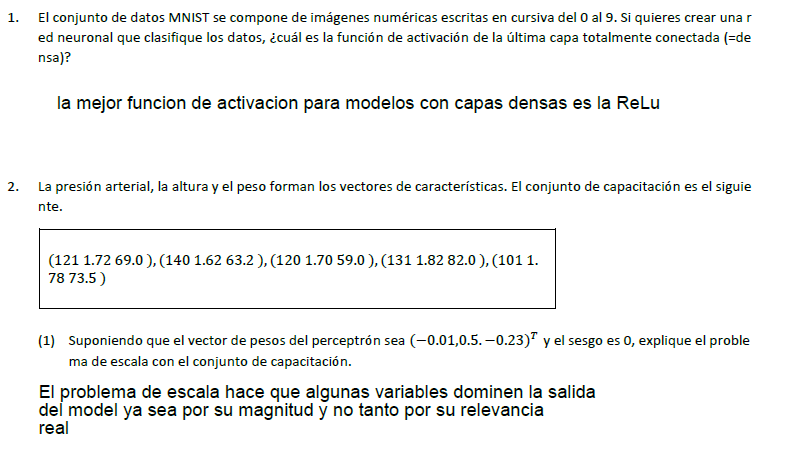

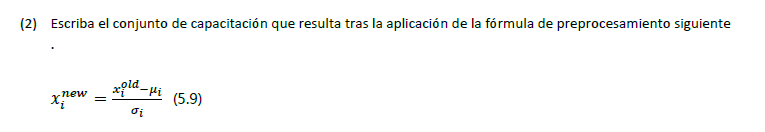

- ### Vector de Medias
obteniendo el vector de la media del conjuto de datos tenemos 
$$
\mu = (122.6, 1.728, 69.34)
$$
- ### Vetor de Desviaciones estandar
obteniendo el vector de la desviacion estandar del conjunto de datos tenemos

$$
\sigma = (13.03, 0.0689, 8.03)
$$
- ### conjuntos de datos estandarizados 
usando los resultados anteriores y aplicando la formula para estandarizar los datos 
tenemos los sig vectores 
$$
\begin{aligned}
(-0.12, -0.12, -0.04) \
(1.34, -1.57, -0.77) \
(-0.20, -0.41, -1.29) \
(0.64, 1.34, 1.58) \
(-1.66, 0.75, 0.52)
\end{aligned}
$$


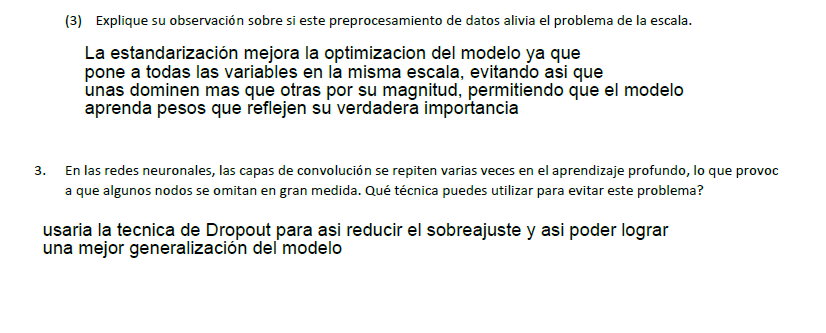

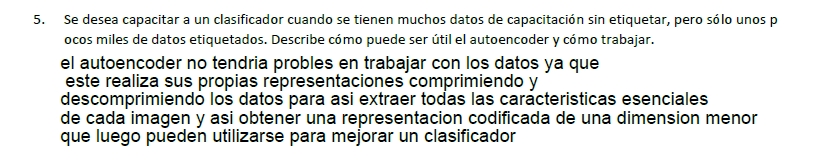

In [7]:
import tensorflow as tf 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from tensorflow.keras import models, layers

from tensorflow.keras.datasets.fashion_mnist import load_data



In [8]:
## Cargamos los datos 
(X_train, y_train),(X_test, y_test) = load_data()

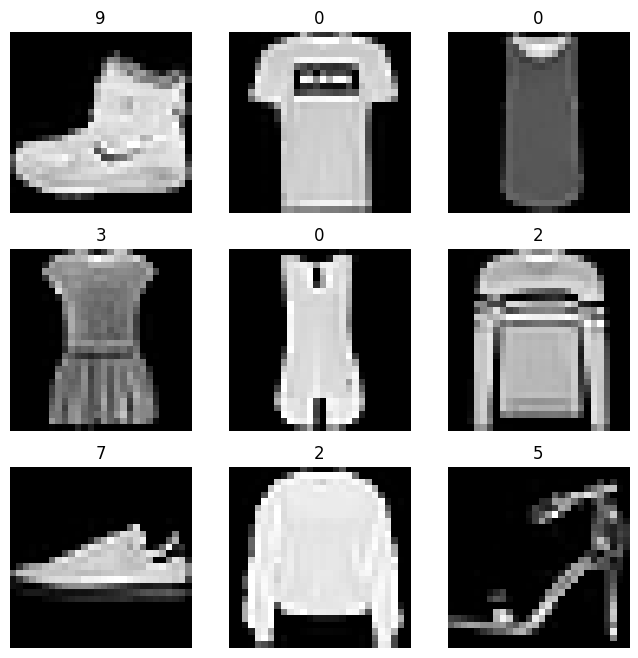

In [9]:
## Visualizacion de los datos 
plt.figure(figsize=(8,8))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(y_train[i])
    plt.axis('off')

plt.show()

In [10]:
## Realizamos el procesamiento de datos 
X_train = X_train.reshape((-1,28,28,1))
X_train = X_train/255
X_test = X_test.reshape((-1,28,28,1))
X_test = X_test/255

## Definimos los parameteos de capacitacion 
batch_size = 8 
n_epochs = 20 
learn_rate  = 0.0001

In [11]:

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learn_rate),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(
    X_train, y_train,
    batch_size=batch_size,
    epochs=n_epochs,
    validation_split=0.1
)

Epoch 1/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 41s 6ms/step - accuracy: 0.7774 - loss: 0.6155 - val_accuracy: 0.8298 - val_loss: 0.4589
Epoch 2/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.8467 - loss: 0.4242 - val_accuracy: 0.8587 - val_loss: 0.3875
Epoch 3/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.8652 - loss: 0.3742 - val_accuracy: 0.8623 - val_loss: 0.3726
Epoch 4/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.8766 - loss: 0.3407 - val_accuracy: 0.8798 - val_loss: 0.3371
Epoch 5/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 40s 5ms/step - accuracy: 0.8846 - loss: 0.3177 - val_accuracy: 0.8857 - val_loss: 0.3144
Epoch 6/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 42s 5ms/step - accuracy: 0.8914 - loss: 0.2978 - val_accuracy: 0.8915 - val_loss: 0.3041
Epoch 7/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.8973 - loss: 0.2828 - val_accuracy: 0.8948 - val_loss: 0.2921
Epoch 8/20
6750/6750 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.9027 - loss: 0

In [14]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print("Accuracy en test:", test_acc)


pred = model.predict(X_test)

# clase predicha
print("Predicción:", np.argmax(pred[0]))
print("Real:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9024 - loss: 0.2785
Accuracy en test: 0.902400016784668
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Predicción: 9
Real: 9
